# **Step 1: Context Discovery**
### **Goal**:
Understand the purpose of clustering for substance use incidents and identify patterns based on age, gender, substance type, and geography.

**Summary**:  
Clustering aims to identify groups in the dataset to reveal insights such as:
- Which age groups are most affected?
- Do substance types vary by neighbourhood?
- Are there patterns in incident times or gender distribution?

# **Step 2: Data Collection**
We load the dataset and verify its structure.

In [32]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Substance Use dataset
data_path = "Substance_Use_20241218.csv"
data = pd.read_csv(data_path)

# Check the first rows of the dataset
data.head()

,Incident Number,Dispatch Date,Patient Number,Age,Gender,Substance,Ward,Neighbourhood ID,Neighbourhood
0,2022528702,06/08/2022 04:11:23 AM,1,35 to 39,Female,Crystal Meth,Mynarski,NE151,Robertson
1,2022528734,06/08/2022 06:57:13 AM,1,55 to 59,Male,Alcohol,St. Boniface,NE027,Central St. Boniface
2,2022528737,06/08/2022 07:00:32 AM,1,20 to 24,Male,Alcohol,St. Vital,NE158,Royalwood
3,2022528750,06/08/2022 08:11:24 AM,1,30 to 34,Male,Opioids,NaN,NaN,NaN
4,2021157921,12/26/2021 12:12:24 AM,1,15 to 19,Male,Marijuana,Transcona,NE060,Grassie


In [34]:
# Display column names and information about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97049 entries, 0 to 97048
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Incident Number   97049 non-null  int64 
 1   Dispatch Date     97049 non-null  object
 2   Patient Number    97049 non-null  int64 
 3   Age               96846 non-null  object
 4   Gender            97048 non-null  object
 5   Substance         97048 non-null  object
 6   Ward              87459 non-null  object
 7   Neighbourhood ID  87449 non-null  object
 8   Neighbourhood     87449 non-null  object
dtypes: int64(2), object(7)
memory usage: 6.7+ MB


# **Step 3: Data Exploration**
We check the distributions of features to understand the data better.

In [37]:
# Check for missing values in each column
print("Missing values in each column:")
data.isnull().sum()

Missing values in each column:


Incident Number        0
Dispatch Date          0
Patient Number         0
Age                  203
Gender                 1
Substance              1
Ward                9590
Neighbourhood ID    9600
Neighbourhood       9600
dtype: int64

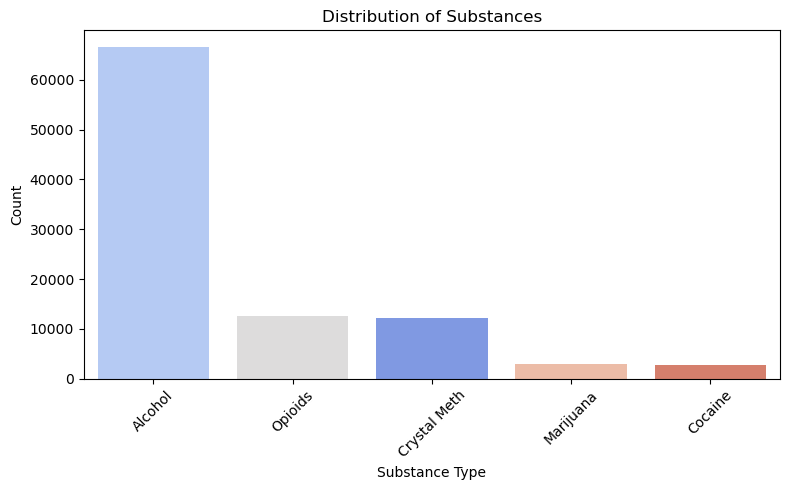

In [68]:
# Distribution of substances (Vertical)
plt.figure(figsize=(8, 5))
sns.countplot(
    x='Substance',  # Switch from 'y' to 'x'
    data=data,
    order=data['Substance'].value_counts().index, 
    hue='Substance',  # Assign hue explicitly
    palette="coolwarm",
    legend=False
)
plt.title("Distribution of Substances")
plt.ylabel("Count")  # Update axis labels
plt.xlabel("Substance Type")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()


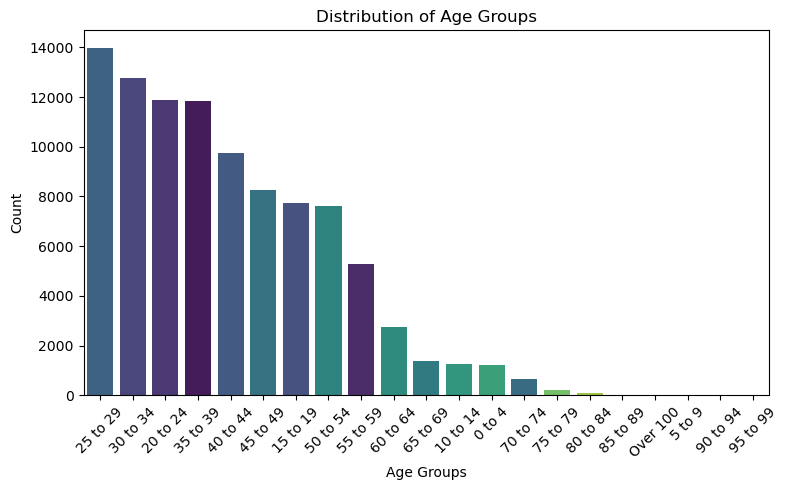

In [81]:
# Age Group Distribution (Vertical) with palette and hue
plt.figure(figsize=(8, 5))
sns.countplot(
    x='Age',
    data=data,
    order=data['Age'].value_counts().index,
    hue='Age',           # Assign hue to 'Age'
    palette='viridis',   # Use the 'viridis' palette
    dodge=False,         # Ensure bars are not offset
    legend=False         # Suppress the legend
)
plt.title("Distribution of Age Groups")
plt.ylabel("Count")
plt.xlabel("Age Groups")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

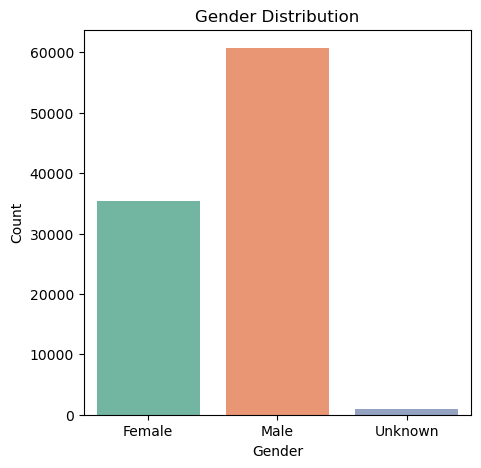

In [89]:
# Gender Distribution
plt.figure(figsize=(5, 5))
sns.countplot(
    x='Gender', 
    data=data, 
    hue='Gender',  # Explicitly specify hue to avoid warnings
    legend=False, 
    palette="Set2"
)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# **Step 4: Data Cleaning**
We handle missing values, duplicates, and any inconsistent data.

In [92]:
# Drop rows with missing 'Ward' or 'Neighbourhood' (important geographic info)
data_cleaned = data.dropna(subset=['Ward', 'Neighbourhood'])

# Replace missing 'Substance' values with "Unknown"
data_cleaned['Substance'].fillna('Unknown', inplace=True)

# Check for duplicates in Incident Number
duplicates = data_cleaned.duplicated(subset=['Incident Number']).sum()
print(f"Number of duplicate Incident Numbers: {duplicates}")

# Drop duplicates if any exist
data_cleaned = data_cleaned.drop_duplicates(subset=['Incident Number'])

# Verify cleaned data
print("Missing values after cleaning:")
data_cleaned.isnull().sum()

Number of duplicate Incident Numbers: 5628
Missing values after cleaning:


/var/folders/qc/ylrp4vq57n590bhgm999r9fw0000gn/T/ipykernel_3240/2394201429.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned['Substance'].fillna('Unknown', inplace=True)
/var/folders/qc/ylrp4vq57n590bhgm999r9fw0000gn/T/ipykernel_3240/2394201429.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['Substance'].fillna(

Incident Number       0
Dispatch Date         0
Patient Number        0
Age                 167
Gender                0
Substance             0
Ward                  0
Neighbourhood ID      0
Neighbourhood         0
dtype: int64

# **Step 5: Data Preprocessing**
Convert categorical data into numerical values and scale numerical features for clustering.

In [54]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode categorical variables
label_encoder = LabelEncoder()

data_cleaned['Gender'] = label_encoder.fit_transform(data_cleaned['Gender'])
data_cleaned['Substance'] = label_encoder.fit_transform(data_cleaned['Substance'])
data_cleaned['Neighbourhood'] = label_encoder.fit_transform(data_cleaned['Neighbourhood'])
data_cleaned['Age'] = label_encoder.fit_transform(data_cleaned['Age'])

# Scale numerical features
scaler = StandardScaler()
data_cleaned[['Gender', 'Substance', 'Age']] = scaler.fit_transform(data_cleaned[['Gender', 'Substance', 'Age']])

# Preview the preprocessed data
print("Preprocessed Data Sample:")
print(data_cleaned[['Gender', 'Substance', 'Age']].head())

Preprocessed Data Sample:
     Gender  Substance       Age
0 -1.312551   0.902471 -0.035185
1  0.696057  -0.553645  1.534192
2  0.696057  -0.553645 -0.976811
4  0.696057   1.630529 -1.290687
5 -1.312551  -0.553645 -0.035185


# **Step 6: Modeling**
We use **K-Means Clustering** to group the data and identify patterns.

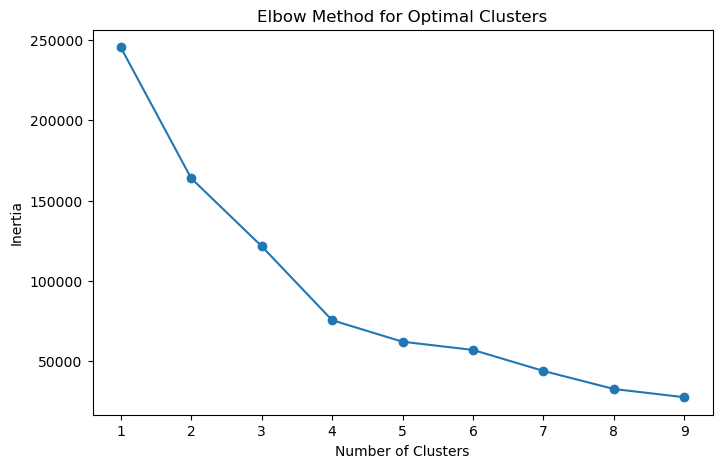

Cluster Assignments:
     Gender  Substance       Age  Cluster
0 -1.312551   0.902471 -0.035185        1
1  0.696057  -0.553645  1.534192        0
2  0.696057  -0.553645 -0.976811        2
4  0.696057   1.630529 -1.290687        3
5 -1.312551  -0.553645 -0.035185        1


In [57]:
from sklearn.cluster import KMeans

# Determine the optimal number of clusters using the Elbow Method
inertia = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_cleaned[['Gender', 'Substance', 'Age']])
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Apply K-Means with optimal k (e.g., 4 clusters as seen in the elbow curve)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data_cleaned['Cluster'] = kmeans.fit_predict(data_cleaned[['Gender', 'Substance', 'Age']])

# Display cluster assignments
print("Cluster Assignments:")
print(data_cleaned[['Gender', 'Substance', 'Age', 'Cluster']].head())


# **Step 7: Validation**
We validate the clustering quality using the **Silhouette Score**.

In [60]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score
silhouette = silhouette_score(data_cleaned[['Gender', 'Substance', 'Age']], data_cleaned['Cluster'])
print(f"Silhouette Score for {optimal_k} clusters: {silhouette}")


Silhouette Score for 4 clusters: 0.4693947275576828


# **Step 8: Data Presentation**
Visualize the clusters and interpret the results.

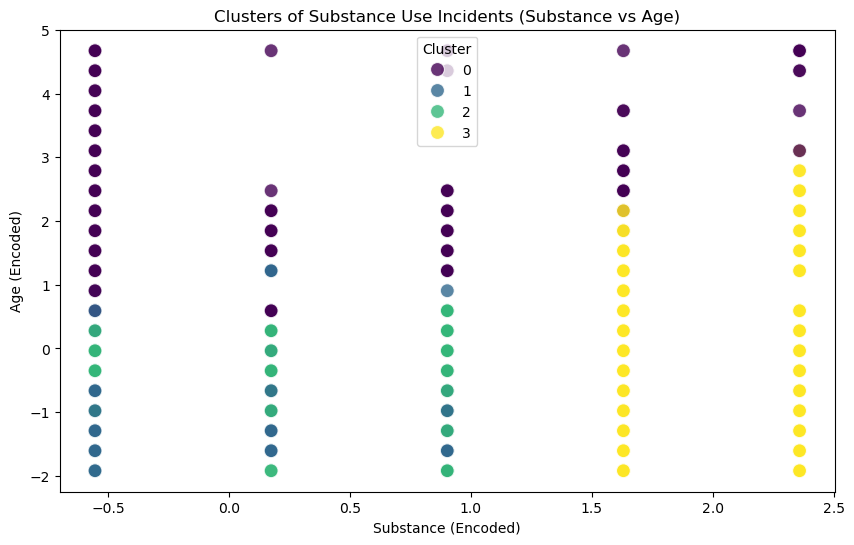

Number of incidents per cluster:
Cluster
2    29937
1    21233
0    20051
3    10600
Name: count, dtype: int64


In [64]:
# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Substance', y='Age', hue='Cluster', data=data_cleaned, palette='viridis', s=100, alpha=0.8
)
plt.title("Clusters of Substance Use Incidents (Substance vs Age)")
plt.xlabel("Substance (Encoded)")
plt.ylabel("Age (Encoded)")
plt.legend(title='Cluster')
plt.show()

# Count of incidents per cluster
cluster_counts = data_cleaned['Cluster'].value_counts()
print("Number of incidents per cluster:")
print(cluster_counts)


# **Conclusion**

1. **Key Insights**:  
   - The data was successfully clustered into groups based on gender, substance type, and age.  
   - Patterns such as specific age groups or substances dominating certain clusters can now be identified.

2. **Cluster Interpretation**:  
   - Each cluster reveals groups with similar characteristics (e.g., certain substances being used by specific age groups).  
   - This analysis can help policymakers and health officials target resources for specific neighbourhoods or demographics.

3. **Next Steps**:  
   - Integrate geographic features like **Neighbourhood** into clustering.  
   - Explore time-based patterns (e.g., incident frequency over months).  
